In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

import openml
import sys
sys.path.append('..')

from src.data_prep import ColumnSelector

- Im więcej danych usuniemy tym wyniki powinny być zauważalnie gorsze
- Co najmniej jeden dataset z p >> n

In [ ]:
from sklearn.discriminant_analysis import StandardScaler


def plot_acc_f1_across_subsets(X, y, n_seeds:int = 3, title: str=''):
    results = {
        "size": [],
        "acc": [],
        "f1": [],
        "bacc": [],
    }

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    sizes = np.arange(0.05, 0.95, 0.1)

    seeds = list(range(n_seeds))

    for size in sizes:
        print(f'Size: {size:.2f}', end=' | ')
        metrics = {"acc": [], "f1": [], "bacc": []}

        for seed in seeds:
            X_train_sub, _, y_train_sub, _ = train_test_split(X_train_full, y_train_full, train_size=size, stratify=y_train_full, random_state=seed)

            if len(np.unique(y_train_sub)) < 2:
                continue

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_sub)
            X_test_scaled = scaler.transform(X_test)

            lr = LogisticRegression(l1_ratio=1, C=1, solver='saga', max_iter=100_000)
            lr.fit(X_train_scaled, y_train_sub.ravel())
            y_hat = lr.predict(X_test_scaled)

            metrics['acc'].append(accuracy_score(y_test, y_hat))
            metrics['f1'].append(f1_score(y_test, y_hat))
            metrics['bacc'].append(balanced_accuracy_score(y_test, y_hat))

        if len(metrics['acc']) > 0:
            avg_acc = np.mean(metrics['acc'])
            avg_f1 = np.mean(metrics['f1'])
            avg_bacc = np.mean(metrics['bacc'])
            
            results['size'].append(size)
            results['acc'].append(avg_acc)
            results['f1'].append(avg_f1)
            results['bacc'].append(avg_bacc)
            
            print(
                f"Acc: {avg_acc:.4f} "
                f"Bacc: {avg_bacc:.4f} "
                f"F1: {avg_f1:.4f} "
                )
        else:
            print("Skipped")

    
    plt.figure(figsize=(10, 6))
    plt.plot(results['size'], results['acc'], marker='o', label='Accuracy')
    plt.plot(results['size'], results['bacc'], marker='^', label='Balanced Accuracy')
    plt.plot(results['size'], results['f1'], marker='s', label='F1-Score')
    
    plt.title(f"{title}")
    plt.xlabel("Proportion of training data")
    plt.ylabel("Metric value (Test data)")
    plt.legend()
    plt.grid(True)
    
    plt.show()

### spam

In [48]:
from ucimlrepo import fetch_ucirepo 

selector = ColumnSelector()
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 

# data (as pandas dataframes) 
spam_X = spambase.data.features .to_numpy()
spam_y = spambase.data.targets.to_numpy()

Size: 0.05 | Acc: 0.8727 Bacc: 0.8633 F1: 0.8339 
Size: 0.15 | Acc: 0.9013 Bacc: 0.8954 F1: 0.8738 
Size: 0.25 | Acc: 0.9115 Bacc: 0.9061 F1: 0.8869 
Size: 0.35 | Acc: 0.9211 Bacc: 0.9165 F1: 0.8994 
Size: 0.45 | Acc: 0.9231 Bacc: 0.9181 F1: 0.9016 
Size: 0.55 | Acc: 0.9225 Bacc: 0.9174 F1: 0.9009 
Size: 0.65 | Acc: 0.9252 Bacc: 0.9202 F1: 0.9043 
Size: 0.75 | Acc: 0.9272 Bacc: 0.9215 F1: 0.9064 
Size: 0.85 | Acc: 0.9270 Bacc: 0.9212 F1: 0.9061 


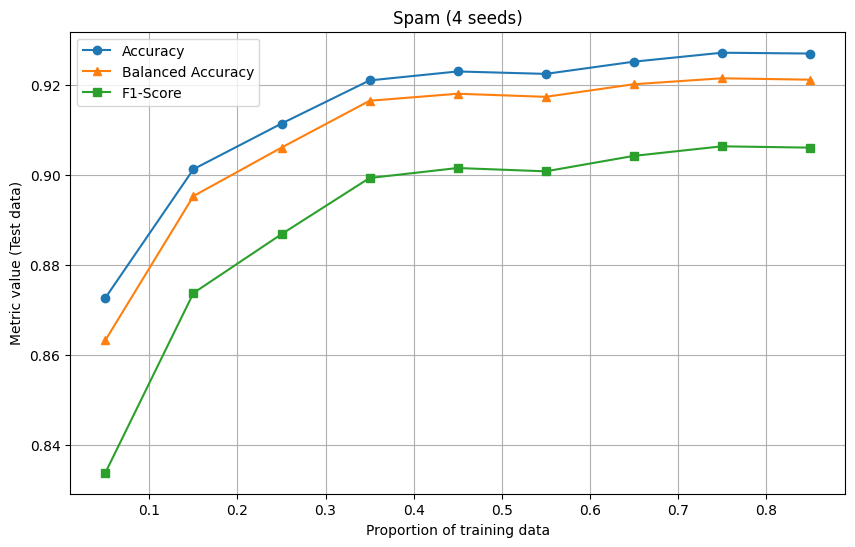

In [78]:
k = 4
plot_acc_f1_across_subsets(spam_X, spam_y, n_seeds=k, title=f'Spam ({k} seeds)')

Not really a big difference (y scale)

### ozone

In [38]:
dataset = openml.datasets.get_dataset(1487)

ozone_X, ozone_y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe"
)

ozone_y = ozone_y.astype(int)
ozone_y = np.where(np.isin(ozone_y, [1]), 0, 1)

Size: 0.05 | Acc: 0.9320 Bacc: 0.5678 F1: 0.2030 
Size: 0.10 | Acc: 0.9330 Bacc: 0.5780 F1: 0.2401 
Size: 0.15 | Acc: 0.9353 Bacc: 0.5890 F1: 0.2588 
Size: 0.20 | Acc: 0.9379 Bacc: 0.6098 F1: 0.3127 
Size: 0.25 | Acc: 0.9356 Bacc: 0.5989 F1: 0.2924 
Size: 0.30 | Acc: 0.9382 Bacc: 0.6051 F1: 0.3135 
Size: 0.35 | Acc: 0.9396 Bacc: 0.6083 F1: 0.3231 
Size: 0.40 | Acc: 0.9412 Bacc: 0.6310 F1: 0.3711 
Size: 0.45 | Acc: 0.9405 Bacc: 0.6331 F1: 0.3741 
Size: 0.50 | Acc: 0.9435 Bacc: 0.6347 F1: 0.3857 
Size: 0.55 | Acc: 0.9445 Bacc: 0.6449 F1: 0.4071 
Size: 0.60 | Acc: 0.9458 Bacc: 0.6480 F1: 0.4166 
Size: 0.65 | Acc: 0.9438 Bacc: 0.6421 F1: 0.3995 
Size: 0.70 | Acc: 0.9432 Bacc: 0.6345 F1: 0.3829 
Size: 0.75 | Acc: 0.9461 Bacc: 0.6482 F1: 0.4175 
Size: 0.80 | Acc: 0.9474 Bacc: 0.6465 F1: 0.4191 
Size: 0.85 | Acc: 0.9474 Bacc: 0.6538 F1: 0.4328 
Size: 0.90 | Acc: 0.9481 Bacc: 0.6541 F1: 0.4359 


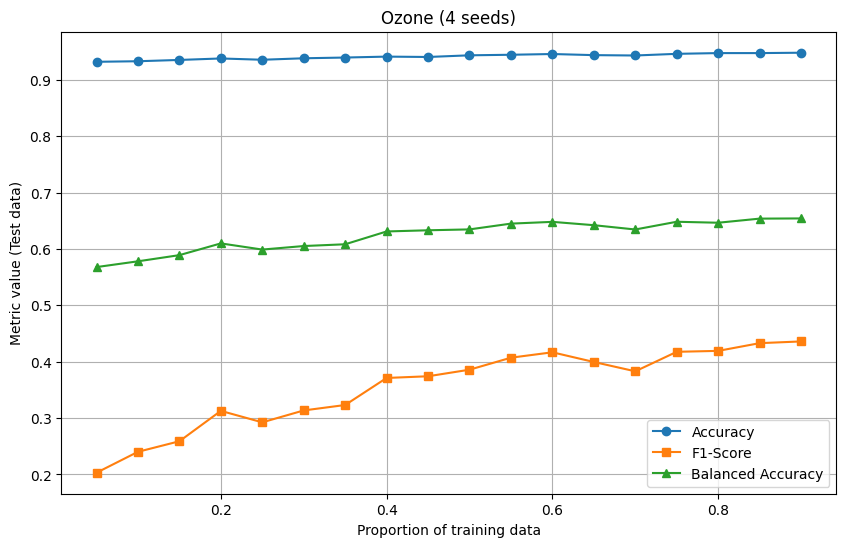

In [44]:
k = 4
plot_acc_f1_across_subsets(ozone_X, ozone_y, n_seeds=k, title=f'Ozone ({k} seeds)')

In terms of F1 a bit better but acc and bacc almost no difference

### prostate

In [ ]:
prostate = pd.read_csv('../data/raw/prostmat.csv', header=None).T

X = prostate.iloc[:, 1:].to_numpy()
y = prostate.iloc[:, 0].to_numpy()
# y = np.where(y == 'cancer', 1, 0)

prostate = pd.read_csv('../data/raw/prostmat.csv', header=None).T

prostate_X = prostate.iloc[:, 1:].to_numpy()
prostate_y = prostate.iloc[:, 0].to_numpy()
prostate_y

array([-0.93089516, -0.83999635,  0.06250801, ...,  0.34722811,
       -0.9013103 , -0.25225949], shape=(6033,))

Size: 0.05 | Acc: 0.5097 Bacc: 0.5021 F1: 0.5274 
Size: 0.15 | Acc: 0.6194 Bacc: 0.6229 F1: 0.5660 
Size: 0.25 | Acc: 0.6065 Bacc: 0.6038 F1: 0.6434 
Size: 0.35 | Acc: 0.6323 Bacc: 0.6329 F1: 0.6314 
Size: 0.45 | Acc: 0.7032 Bacc: 0.7021 F1: 0.7154 
Size: 0.55 | Acc: 0.7613 Bacc: 0.7617 F1: 0.7612 
Size: 0.65 | Acc: 0.7419 Bacc: 0.7408 F1: 0.7448 
Size: 0.75 | Acc: 0.7548 Bacc: 0.7562 F1: 0.7496 
Size: 0.85 | Acc: 0.8323 Bacc: 0.8337 F1: 0.8282 


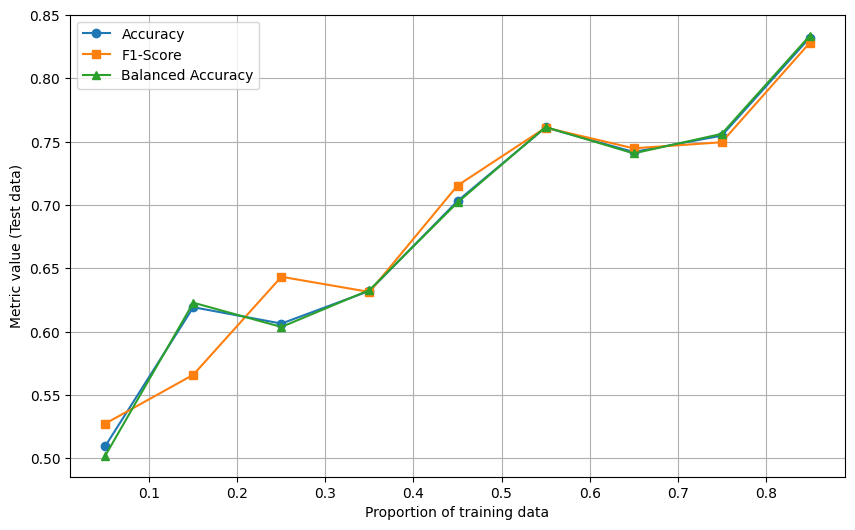

In [54]:
k = 3
plot_acc_f1_across_subsets(X, y, n_seeds=5, title=f'Prostate ({k} seeds')

Ideal (and p >> n)

### darwin

Size: 0.05 | Acc: 0.6264 Bacc: 0.6298 F1: 0.5421 
Size: 0.15 | Acc: 0.6906 Bacc: 0.6916 F1: 0.6684 
Size: 0.25 | Acc: 0.7019 Bacc: 0.7028 F1: 0.6883 
Size: 0.35 | Acc: 0.7075 Bacc: 0.7091 F1: 0.6801 
Size: 0.45 | Acc: 0.7019 Bacc: 0.7031 F1: 0.6848 
Size: 0.55 | Acc: 0.7528 Bacc: 0.7539 F1: 0.7395 
Size: 0.65 | Acc: 0.7509 Bacc: 0.7515 F1: 0.7462 
Size: 0.75 | Acc: 0.7472 Bacc: 0.7476 F1: 0.7448 
Size: 0.85 | Acc: 0.7434 Bacc: 0.7434 F1: 0.7462 


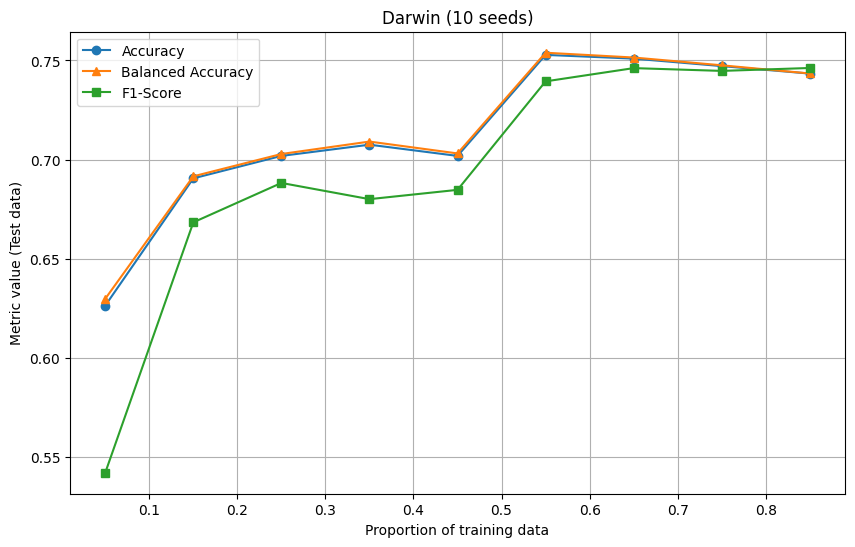

In [75]:
darwin = pd.read_csv('../data/raw/DARWIN.csv')

X = darwin.iloc[:, 1:-1].to_numpy()
y = darwin.iloc[:, -1].to_numpy()
y = np.where(y == 'P', 1, 0)

k = 10
plot_acc_f1_across_subsets(X, y, n_seeds=k, title=f'Darwin ({k} seeds)')

Also quite ok

### bankrupcy

In [73]:
bankrupcy = pd.read_csv('../data/raw/bankrupcy.csv')

X = bankrupcy.iloc[:, 1:].to_numpy()
y = bankrupcy.iloc[:, 0].to_numpy()

Size: 0.05 | Acc: 0.9589 Bacc: 0.6163 F1: 0.2707 
Size: 0.15 | Acc: 0.9602 Bacc: 0.5840 F1: 0.2273 
Size: 0.25 | Acc: 0.9614 Bacc: 0.6102 F1: 0.2800 
Size: 0.35 | Acc: 0.9604 Bacc: 0.6061 F1: 0.2714 
Size: 0.45 | Acc: 0.9638 Bacc: 0.6225 F1: 0.3142 
Size: 0.55 | Acc: 0.9653 Bacc: 0.6269 F1: 0.3308 
Size: 0.65 | Acc: 0.9646 Bacc: 0.6229 F1: 0.3193 
Size: 0.75 | Acc: 0.9663 Bacc: 0.6274 F1: 0.3365 
Size: 0.85 | Acc: 0.9638 Bacc: 0.6152 F1: 0.3019 


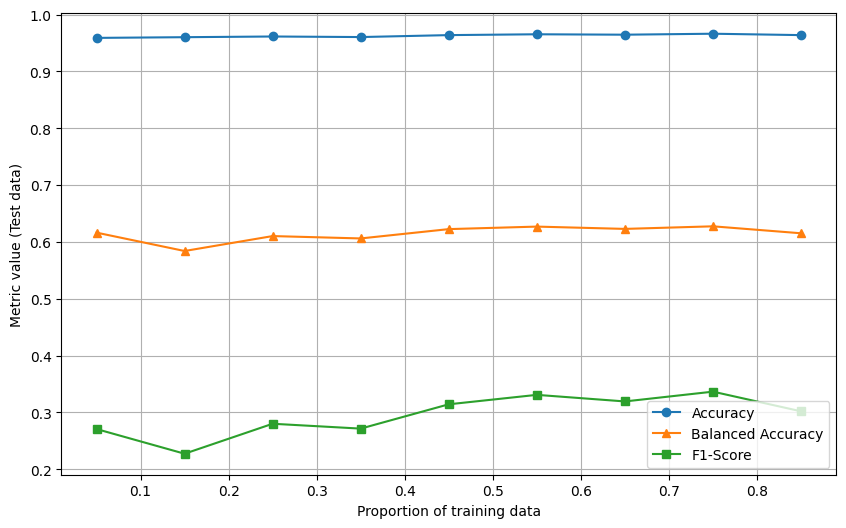

In [74]:
plot_acc_f1_across_subsets(X, y, n_seeds=2)

No difference

Size: 0.05 | Acc: 0.7586 Bacc: 0.6272 F1: 0.8462 
Size: 0.15 | Acc: 0.7797 Bacc: 0.6618 F1: 0.8587 
Size: 0.25 | Acc: 0.7885 Bacc: 0.6813 F1: 0.8637 
Size: 0.35 | Acc: 0.7921 Bacc: 0.6837 F1: 0.8663 
Size: 0.45 | Acc: 0.7938 Bacc: 0.6939 F1: 0.8663 
Size: 0.55 | Acc: 0.8097 Bacc: 0.7114 F1: 0.8772 
Size: 0.65 | Acc: 0.8256 Bacc: 0.7390 F1: 0.8866 
Size: 0.75 | Acc: 0.8370 Bacc: 0.7546 F1: 0.8940 
Size: 0.85 | Acc: 0.8335 Bacc: 0.7477 F1: 0.8919 


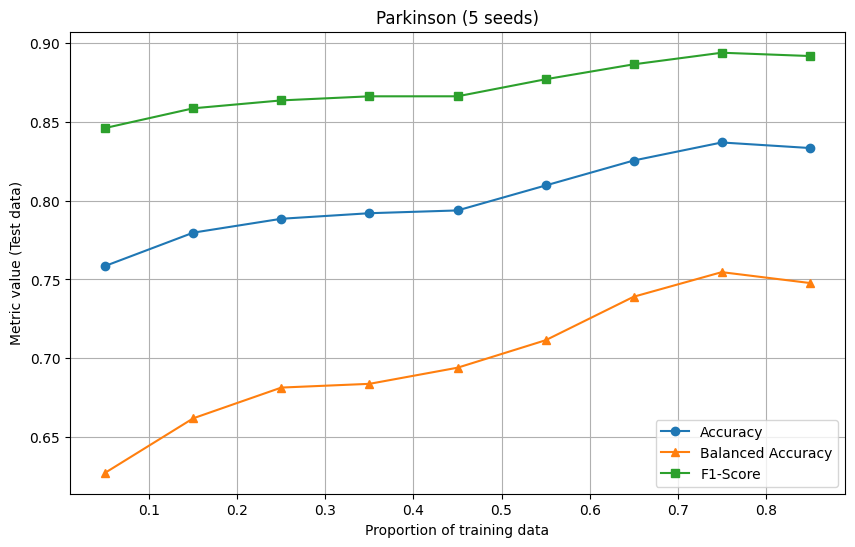

In [77]:
parkinson = pd.read_csv('../data/raw/parkinson.csv')
X = parkinson.iloc[:, 1:-1].to_numpy()
y = parkinson.iloc[:, -1].to_numpy()

k = 5

plot_acc_f1_across_subsets(X, y, n_seeds=k, title=f'Parkinson ({k} seeds)')

Not great not terrible

Size: 0.05 | Acc: 0.5833 Bacc: 0.5493 F1: 0.4030 
Size: 0.15 | Acc: 0.5897 Bacc: 0.4936 F1: 0.2369 
Size: 0.25 | Acc: 0.5769 Bacc: 0.5244 F1: 0.3653 
Size: 0.35 | Acc: 0.6346 Bacc: 0.5521 F1: 0.3582 
Size: 0.45 | Acc: 0.5641 Bacc: 0.4745 F1: 0.2473 
Size: 0.55 | Acc: 0.5449 Bacc: 0.4854 F1: 0.3151 
Size: 0.65 | Acc: 0.5192 Bacc: 0.4412 F1: 0.2274 
Size: 0.75 | Acc: 0.4872 Bacc: 0.4022 F1: 0.1616 
Size: 0.85 | Acc: 0.5000 Bacc: 0.4168 F1: 0.1856 


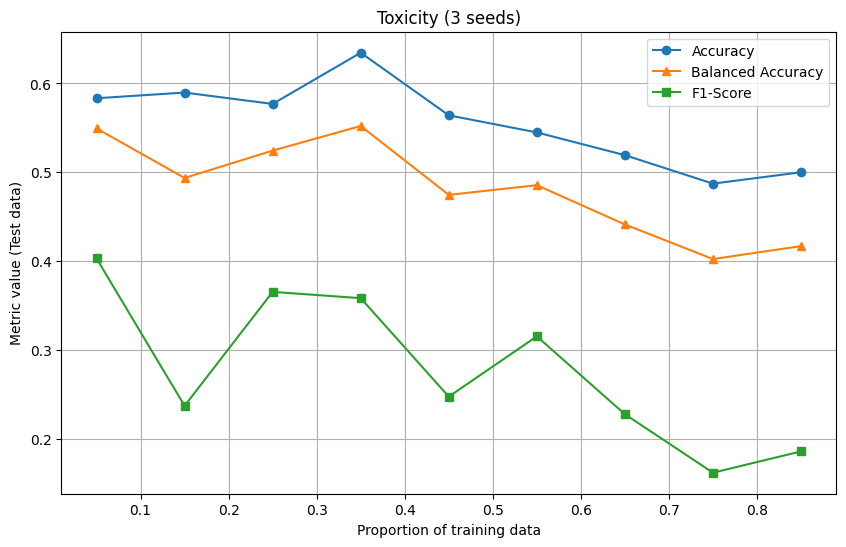

In [76]:
toxicity = pd.read_csv('../data/raw/toxicity.csv')
X = toxicity.iloc[:, :-1].to_numpy()
y = toxicity.iloc[:, -1].to_numpy()
y = np.where(y =='Toxic', 1, 0)

k = 3
plot_acc_f1_across_subsets(X, y, k, f'Toxicity ({k} seeds)')

wtf xd